C:\Users\hp\AppData\Local\Temp\ipykernel_11888\41918670.py:21: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  date_range = pd.date_range(start='2024-01-01', periods=180*24, freq='H')
C:\Users\hp\AppData\Local\Temp\ipykernel_11888\41918670.py:60: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


Missing values before cleaning:
datetime               0
hour                   0
day                    0
month                  0
day_of_week            0
is_weekend             0
temperature           50
humidity              50
energy_consumption     0
dtype: int64

Missing values after cleaning:
datetime              0
hour                  0
day                   0
month                 0
day_of_week           0
is_weekend            0
temperature           0
humidity              0
energy_consumption    0
dtype: int64

Dataset Preview:
             datetime  hour  day  month  day_of_week  is_weekend  temperature  \
3 2024-01-01 03:00:00     3    1      1            0           0    35.117128   
4 2024-01-01 04:00:00     4    1      1            0           0    33.191947   
5 2024-01-01 05:00:00     5    1      1            0           0    34.190984   
6 2024-01-01 06:00:00     6    1      1            0           0    38.158426   
7 2024-01-01 07:00:00     7    1      1       

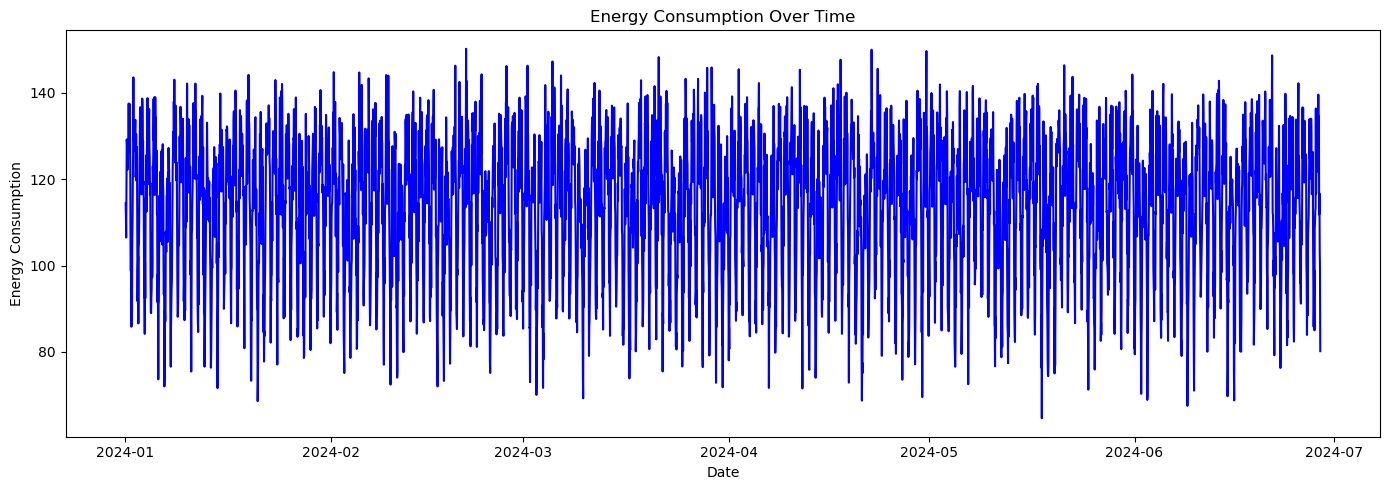

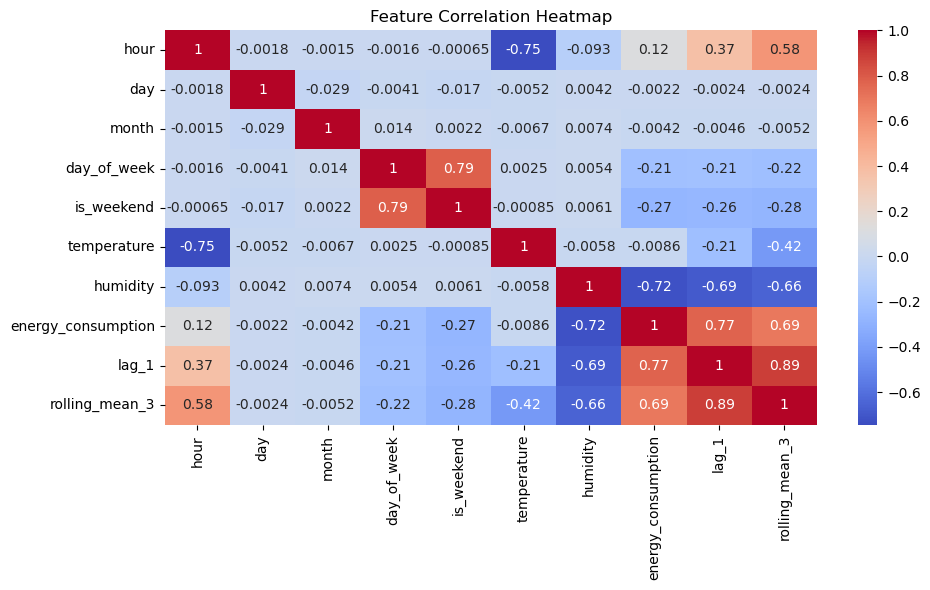


===== Model Performance =====
RMSE : 5.53
MAE  : 4.45
R² Score : 0.8780

Feature Importance:
          Feature  Importance
6        humidity    0.564564
5     temperature    0.146299
7           lag_1    0.132505
0            hour    0.062382
8  rolling_mean_3    0.029134
3     day_of_week    0.026665
4      is_weekend    0.024105
1             day    0.009887
2           month    0.004460


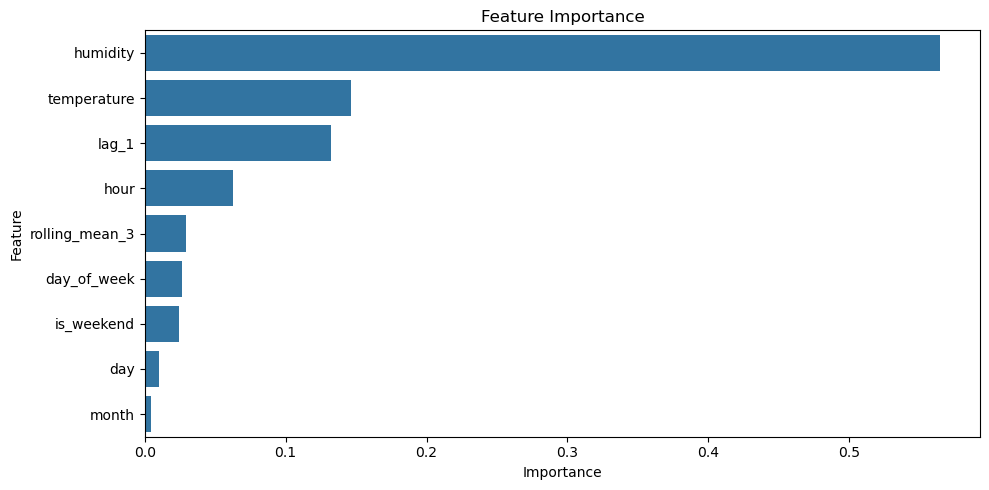

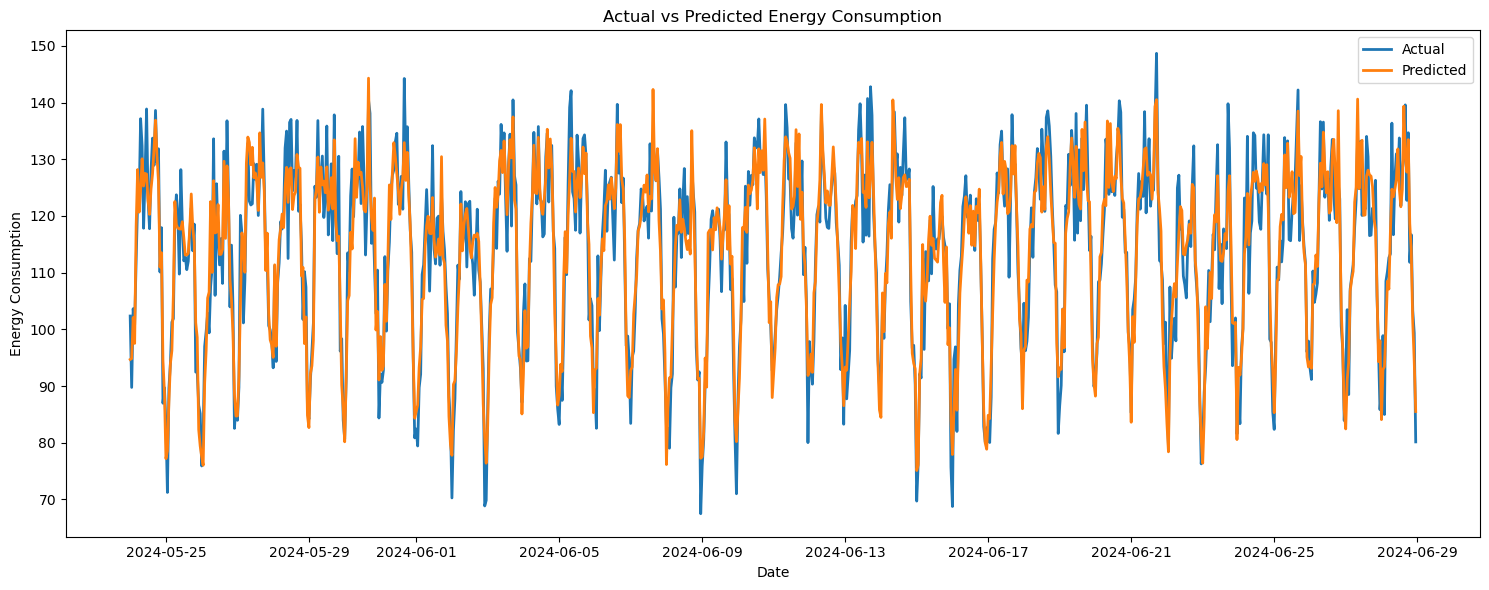

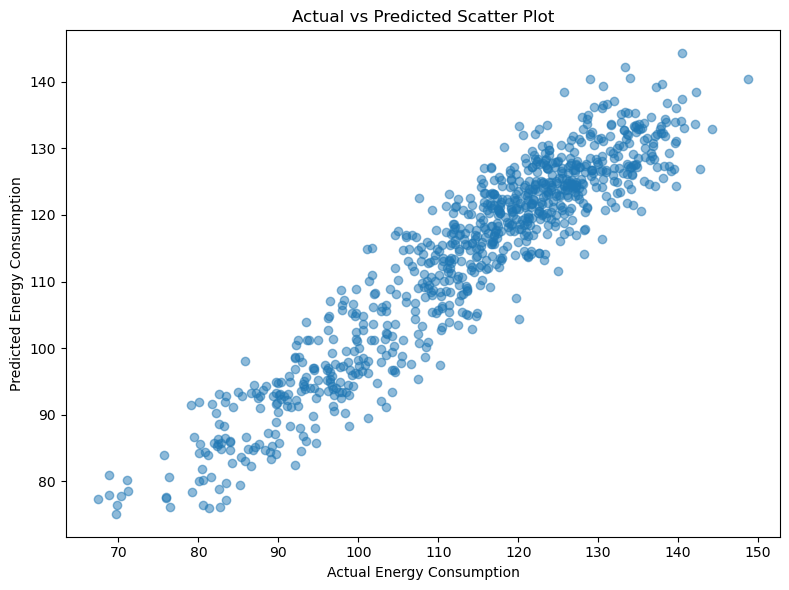


Files saved:
- predictions.csv
- feature_importance.csv

Project completed successfully!


In [4]:
# ==========================================
# AI-Powered Energy Consumption Forecasting
# ==========================================

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# -----------------------------
# 2. Generate Synthetic Dataset
# -----------------------------
np.random.seed(42)

# Create hourly timestamps for 180 days
date_range = pd.date_range(start='2024-01-01', periods=180*24, freq='H')

df = pd.DataFrame()
df['datetime'] = date_range

# Extract time-based features
df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month
df['day_of_week'] = df['datetime'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# Generate synthetic weather data
df['temperature'] = 25 + 10 * np.sin(2 * np.pi * df['hour'] / 24) + np.random.normal(0, 2, len(df))
df['humidity'] = 60 + 20 * np.cos(2 * np.pi * df['hour'] / 24) + np.random.normal(0, 5, len(df))

# Generate synthetic energy consumption
base_load = 100
hourly_pattern = 20 * np.sin(2 * np.pi * (df['hour'] - 8) / 24)
weekend_effect = -10 * df['is_weekend']
temperature_effect = 2.5 * np.abs(df['temperature'] - 22)
random_noise = np.random.normal(0, 5, len(df))

df['energy_consumption'] = base_load + hourly_pattern + weekend_effect + temperature_effect + random_noise

# -----------------------------
# 3. Introduce Missing Values
# -----------------------------
for col in ['temperature', 'humidity']:
    missing_idx = np.random.choice(df.index, size=50, replace=False)
    df.loc[missing_idx, col] = np.nan

# -----------------------------
# 4. Data Cleaning
# -----------------------------
print("Missing values before cleaning:")
print(df.isnull().sum())

# Fill missing values using forward fill
df.fillna(method='ffill', inplace=True)

print("\nMissing values after cleaning:")
print(df.isnull().sum())

# -----------------------------
# 5. Feature Engineering
# -----------------------------
# Lag feature: previous hour consumption
df['lag_1'] = df['energy_consumption'].shift(1)

# Rolling mean of previous 3 hours
df['rolling_mean_3'] = df['energy_consumption'].shift(1).rolling(window=3).mean()

# Drop rows with NaN after lag/rolling
df.dropna(inplace=True)

# -----------------------------
# 6. Exploratory Data Analysis
# -----------------------------
print("\nDataset Preview:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

# Plot energy consumption over time
plt.figure(figsize=(14, 5))
plt.plot(df['datetime'], df['energy_consumption'], color='blue')
plt.title('Energy Consumption Over Time')
plt.xlabel('Date')
plt.ylabel('Energy Consumption')
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.drop(columns=['datetime']).corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# -----------------------------
# 7. Prepare Features and Target
# -----------------------------
features = [
    'hour', 'day', 'month', 'day_of_week', 'is_weekend',
    'temperature', 'humidity', 'lag_1', 'rolling_mean_3'
]

target = 'energy_consumption'

X = df[features]
y = df[target]

# Time-based split (important for forecasting)
split_index = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
test_dates = df['datetime'].iloc[split_index:]

# -----------------------------
# 8. Build and Train Model
# -----------------------------
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# -----------------------------
# 9. Predictions
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# 10. Model Evaluation
# -----------------------------
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n===== Model Performance =====")
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"R² Score : {r2:.4f}")

# -----------------------------
# 11. Feature Importance
# -----------------------------
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

plt.figure(figsize=(10, 5))
sns.barplot(data=feature_importance, x='Importance', y='Feature')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

# -----------------------------
# 12. Actual vs Predicted Plot
# -----------------------------
results = pd.DataFrame({
    'datetime': test_dates.values,
    'Actual': y_test.values,
    'Predicted': y_pred
})

plt.figure(figsize=(15, 6))
plt.plot(results['datetime'], results['Actual'], label='Actual', linewidth=2)
plt.plot(results['datetime'], results['Predicted'], label='Predicted', linewidth=2)
plt.title('Actual vs Predicted Energy Consumption')
plt.xlabel('Date')
plt.ylabel('Energy Consumption')
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 13. Scatter Plot
# -----------------------------
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual Energy Consumption')
plt.ylabel('Predicted Energy Consumption')
plt.title('Actual vs Predicted Scatter Plot')
plt.tight_layout()
plt.show()

# -----------------------------
# 14. Save Results
# -----------------------------
results.to_csv("predictions.csv", index=False)
feature_importance.to_csv("feature_importance.csv", index=False)

print("\nFiles saved:")
print("- predictions.csv")
print("- feature_importance.csv")
print("\nProject completed successfully!")
